# Explore extracted OSM road ways

Read the extracted OSM Highway, check quality, generate statistic on name road and type, and visualize.

- Statistics apply for **OSM ways**, not physical real road - A physical real road may consist many way, and two-way roads have many separate geometries
- `name` already applied during extraction, so it maybe old_name or alternative name or reference name.

---

- **Run** `uv sync --group notebook`, 
- open notebook and **select kernel** `.venv/bin/python`.

In [1]:
import os
from pathlib import Path

# Locate the project from either the repository root or the notebooks directory.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").is_file()),
    Path.cwd(),
)

In [2]:
OSM_PARQUET_DEFAULT_PATH = "data/hcm_ways_raw.parquet"

PARQUET_PATH = Path(os.getenv("OSM_PARQUET_PATH", OSM_PARQUET_DEFAULT_PATH))

if not PARQUET_PATH.is_absolute():
    PARQUET_PATH = PROJECT_ROOT / PARQUET_PATH
EXTENSION_DIRECTORY = Path(
    os.getenv(
        "OSM_DUCKDB_EXTENSION_DIR", str(PROJECT_ROOT / ".cache/osm-road-weaver/duckdb/extensions")
    )
)

# Set a fixed random seed for reproducibility
SEED = 42

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache/matplotlib"))
if not PARQUET_PATH.is_file():
    raise FileNotFoundError(f"Extract the region first or update PARQUET_PATH: {PARQUET_PATH}")
print(PARQUET_PATH)

/Users/khoavu/Documents/Projects/MCILab/osm-road-weaver/data/hcm_ways_raw.parquet


In [3]:
import html
import json

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
from IPython.display import HTML, display
from pyproj import CRS

plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    }
)

## 1. Metadata, Schema And Data Sample

In [4]:
parquet_metadata = pq.read_metadata(PARQUET_PATH)
schema = pq.read_schema(PARQUET_PATH)
geo = json.loads((schema.metadata or {}).get(b"geo", b"{}"))

geometry_metadata = geo.get("columns", {}).get("geometry", {})

source_crs = geometry_metadata.get("crs", "OGC:CRS84")

if geometry_metadata.get("encoding") != "WKB" or source_crs is None:
    raise ValueError("Expected GeoParquet with WKB geometry and a known CRS")

if not CRS(source_crs).equals(CRS(4326), ignore_axis_order=True):
    raise ValueError("This notebook expects WGS84 coordinates")

required = {"osm_way_id", "name", "highway", "bridge", "geometry"}
if not required.issubset(schema.names):
    raise ValueError(f"Missing columns: {required - set(schema.names)}")

print(f"Rows: {parquet_metadata.num_rows:,}")
print(f"Size: {PARQUET_PATH.stat().st_size / 1024**2:.2f} MiB")
print(f"Row groups: {parquet_metadata.num_row_groups}")
print(f"CRS: {CRS(source_crs).to_string()}")
print(schema.remove_metadata())
provenance = json.loads((schema.metadata or {}).get(b"osm_way_stroke", b"{}"))
print(json.dumps(provenance, ensure_ascii=False, indent=2))

Rows: 216,255
Size: 17.44 MiB
Row groups: 3
CRS: EPSG:4326
osm_way_id: int64
name: string
highway: string
bridge: string
junction: string
geometry: binary
{
  "region_query": "Hồ Chí Minh",
  "region_name": "Ho Chi Minh City, Vietnam",
  "osm_relation_id": 1973756,
  "source_parquet": ".cache/osm-road-weaver/pbf/760602d1_c921037f_alltags_compact_sorted.parquet",
  "source_pbf": null,
  "source_pbf_sha256": null,
  "boundary_sha256": "9cec8ff887b528c8c46ad5724f9d017f0391552b3c2a93a88a29a5902d0726a4",
  "quackosm_version": "0.19.0",
  "attribution": "© OpenStreetMap contributors; ODbL 1.0",
  "boundary_behavior": "QuackOSM node-based selection; no clipping or simplification"
}


In [5]:
# Use the extension already installed by extraction; do not download extensions here.
if "connection" in globals():
    globals()["connection"].close()

connection = duckdb.connect(
    config={
        "extension_directory": str(EXTENSION_DIRECTORY),
        "memory_limit": "2GB",
        "threads": 2,
    }
)
connection.execute("LOAD spatial")
connection.execute("SET enable_geoparquet_conversion = false")
connection.read_parquet(str(PARQUET_PATH)).create_view("raw_ways")

connection.execute("""
    CREATE VIEW ways AS
    SELECT * EXCLUDE (geometry), ST_GeomFromWKB(geometry) AS geometry FROM raw_ways
""")


def show_table(sql: str, limit: int = 20) -> None:
    """Render only a bounded query result as an HTML table."""
    result = connection.sql(sql).limit(limit)
    header = "".join(f"<th>{html.escape(column)}</th>" for column in result.columns)
    rows = "".join(
        "<tr>"
        + "".join(
            f"<td>{html.escape('NULL' if value is None else str(value))}</td>" for value in row
        )
        + "</tr>"
        for row in result.fetchall()
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{rows}</tbody></table>"))


show_table("""
    SELECT * EXCLUDE (geometry), left(ST_AsText(geometry), 120) AS geometry_preview
    FROM ways ORDER BY osm_way_id LIMIT 10
""")

osm_way_id,name,highway,bridge,junction,geometry_preview
31096786,Đường Lê Đức Anh,trunk,NULL,NULL,"LINESTRING (106.6012621 10.7246673, 106.6014811 10.7258087, 106.6017813 10.7277248)"
32563410,NULL,service,NULL,NULL,"LINESTRING (106.8669493 10.5005074, 106.8672761 10.5006766, 106.8680173 10.5010257)"
32563439,Đường Số 12,residential,NULL,NULL,"LINESTRING (106.7496467 10.6349922, 106.7497953 10.6350854, 106.7504287 10.6354262, 106.7507715 10.6356119, 106.7513739"
32563443,NULL,residential,NULL,NULL,"LINESTRING (106.764396 10.4769749, 106.7646073 10.4766598, 106.7648043 10.4763442, 106.7652005 10.4757521, 106.76533 10."
32563458,NULL,service,NULL,NULL,"LINESTRING (106.7673224 10.4720207, 106.7675696 10.4716789, 106.7676917 10.4715172, 106.7681359 10.4709531, 106.7682413"
32563461,NULL,track,NULL,NULL,"LINESTRING (106.7582765 10.5146169, 106.7593574 10.5147158, 106.7616611 10.5148329, 106.7625936 10.5148709, 106.7650931"
32563463,NULL,residential,NULL,NULL,"LINESTRING (106.9584502 10.4181529, 106.9587728 10.4182861, 106.959077 10.4184148, 106.9599185 10.4188165)"
32563467,NULL,tertiary,NULL,NULL,"LINESTRING (106.7675077 10.5331746, 106.7674795 10.5335298, 106.7674263 10.5339109, 106.7673759 10.5342716)"
32563471,NULL,track,NULL,NULL,"LINESTRING (106.7654168 10.5099514, 106.7612452 10.5097584, 106.7582702 10.5096374)"
32563534,NULL,track,NULL,NULL,"LINESTRING (106.7582422 10.5166107, 106.7646717 10.5170835)"


## 2. Statistic

In [6]:
show_table("""
    SELECT count(*) AS ways,
        count(DISTINCT osm_way_id) AS unique_ids,
        count(*) FILTER (WHERE osm_way_id IS NULL) AS null_ids,
        count(osm_way_id) - count(DISTINCT osm_way_id) AS duplicate_ids,
        count(*) FILTER (WHERE name IS NULL OR regexp_full_match(name, '\s*')) AS unnamed,
        round(100.0 * count(*) FILTER (
            WHERE name IS NULL OR regexp_full_match(name, '\s*')
        ) / nullif(count(*), 0), 2) AS unnamed_pct,
        count(*) FILTER (WHERE highway IS NULL) AS null_highway,
        count(*) FILTER (WHERE geometry IS NULL) AS null_geometry,
        count(*) FILTER (WHERE NOT ST_IsValid(geometry)) AS invalid_geometry,
        count(*) FILTER (WHERE ST_IsEmpty(geometry)) AS empty_geometry
    FROM ways
""")

show_table(
    "SELECT ST_GeometryType(geometry) AS geometry_type, count(*) AS ways "
    "FROM ways GROUP BY 1 ORDER BY ways DESC"
)

show_table("SELECT bridge, count(*) AS ways FROM ways GROUP BY bridge ORDER BY ways DESC")
if "junction" in schema.names:
    show_table("SELECT junction, count(*) AS ways FROM ways GROUP BY junction ORDER BY ways DESC")

<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/ry/d04zm9lj2hs_lt3fgnqp6g0c0000gp/T/ipykernel_34183/35928967.py:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  count(*) FILTER (WHERE name IS NULL OR regexp_full_match(name, '\s*')) AS unnamed,


ways,unique_ids,null_ids,duplicate_ids,unnamed,unnamed_pct,null_highway,null_geometry,invalid_geometry,empty_geometry
216255,216255,0,0,152688,70.61,0,0,0,0


geometry_type,ways
LINESTRING,216255


bridge,ways
NULL,211299
yes,4936
viaduct,20


junction,ways
NULL,215645
roundabout,606
circular,4


In [7]:
show_table(
    """
    SELECT highway, count(*) AS ways,
        round(100.0 * count(*) FILTER (
            WHERE name IS NULL OR regexp_full_match(name, '\s*')
        ) / count(*), 2) AS unnamed_pct
    FROM ways GROUP BY highway ORDER BY ways DESC
    """,
    limit=30,
)

show_table("""
    SELECT name, count(*) AS ways
    FROM ways WHERE name IS NOT NULL AND NOT regexp_full_match(name, '\s*')
    GROUP BY name ORDER BY ways DESC, name LIMIT 20
""")

<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:14: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/ry/d04zm9lj2hs_lt3fgnqp6g0c0000gp/T/ipykernel_34183/1710356911.py:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  WHERE name IS NULL OR regexp_full_match(name, '\s*')
/var/folders/ry/d04zm9lj2hs_lt3fgnqp6g0c0000gp/T/ipykernel_34183/1710356911.py:14: SyntaxWarning: "\s"

highway,ways,unnamed_pct
residential,102761,72.38
service,75542,76.45
footway,8451,99.43
tertiary,5416,13.74
secondary,4505,3.24
primary,4049,2.91
unclassified,3276,90.08
track,2788,99.43
trunk,2330,1.16
primary_link,1304,80.98


name,ways
Võ Văn Kiệt,328
Nguyễn Văn Linh,263
Đỗ Mười,256
Võ Nguyên Giáp,215
Đường D1,193
Đường số 1,193
Xa lộ Hà Nội,170
Đường D2,169
Đường Số 1,165
Phạm Văn Đồng,163


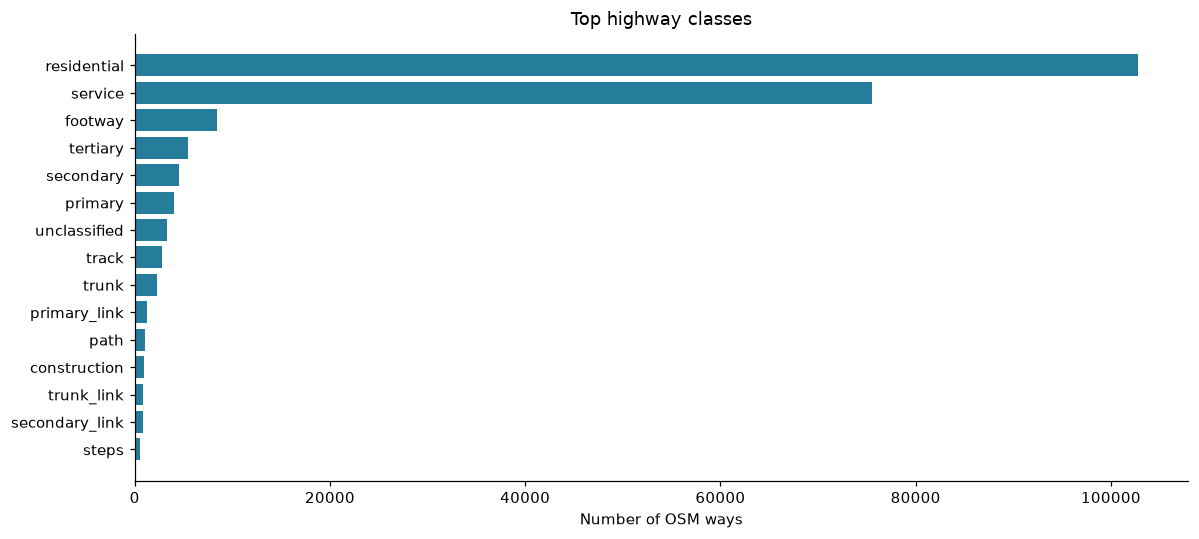

In [8]:
counts = connection.sql("""
    SELECT coalesce(highway, '(null)') AS highway, count(*) AS n
    FROM ways GROUP BY highway ORDER BY n DESC LIMIT 15
""").fetchall()
fig, axis = plt.subplots(figsize=(11, 5))
axis.barh([row[0] for row in counts][::-1], [row[1] for row in counts][::-1], color="#267c9b")
axis.set(title="Top highway classes", xlabel="Number of OSM ways")
fig.tight_layout()
plt.show()

## 4. Map Visualization

- `INTERACTIVE_MAP_LIMIT = None`: Show all valid way, Set a positive interger (e.g., 500_000) to perform deterministic sampling based on hash ID and `seed`, reducing RAM/GPU usage.
- `CRS: EPSG:4326`
- `USE_BASEMAP = False` Do not load basemap. Set `True` to use default basemap of Lonboard. Loading basemap need Internet. Widget also need frontend support Jupyter widgets/WebGL.
- Run `uv sync --group notebook`, select kernel `.venv/bin/python`, then run each cell. If VS Code only displays the text representation of the widget, check the Jupyter extension and the widget renderer.

---

API: [Lonboard PathLayer](https://developmentseed.org/lonboard/latest/api/layers/path-layer/).

In [11]:
import ipywidgets as widgets
from lonboard import Map, PathLayer

INTERACTIVE_MAP_LIMIT = None  # Set to None to render all valid ways.
USE_BASEMAP = False

if INTERACTIVE_MAP_LIMIT is not None and INTERACTIVE_MAP_LIMIT < 1:
    raise ValueError("INTERACTIVE_MAP_LIMIT must be positive or None")

limit_sql = "" if INTERACTIVE_MAP_LIMIT is None else f"LIMIT {int(INTERACTIVE_MAP_LIMIT)}"

connection.execute(f"""
    CREATE OR REPLACE TEMP TABLE interactive_ways AS
    SELECT osm_way_id, name, highway, bridge, geometry,
           name IS NOT NULL AND NOT regexp_full_match(name, '\\s*') AS is_named
    FROM ways
    WHERE ST_IsValid(geometry) AND NOT ST_IsEmpty(geometry)
      AND ST_GeometryType(geometry) = 'LINESTRING'
    ORDER BY hash(osm_way_id, {int(SEED)}), osm_way_id
    {limit_sql}
""")

In [12]:
interactive_relation = connection.sql("SELECT * FROM interactive_ways ORDER BY osm_way_id")

attributes = interactive_relation.project("highway, is_named").fetchnumpy()
if len(attributes["highway"]) == 0:
    raise ValueError("No valid LineStrings to display")

major_classes = [
    "tertiary",
    "primary",
    "secondary",
    "residential",
    "alley",
    "trunk",
    "primary_link",
    "secondary_link",
    "tertiary_link",
    "trunk_link",
    "motorway",
    "motorway_link"
]

major_mask = np.isin(attributes["highway"], major_classes)
highway_colors = np.where(major_mask[:, None], [201, 90, 53, 220], [52, 122, 150, 190]).astype(
    "uint8"
)

named_colors = np.where(
    attributes["is_named"][:, None], [52, 122, 150, 220], [216, 137, 61, 220]
).astype("uint8")

road_layer = PathLayer.from_duckdb(
    interactive_relation.project("osm_way_id, name, highway, bridge, geometry"),
    crs="EPSG:4326",
    get_color=highway_colors,
    width_min_pixels=1.2,
    pickable=True,
    auto_highlight=True,
)

map_options = {} if USE_BASEMAP else {"basemap": None}
interactive_map = Map(
    road_layer,
    height=650,
    show_tooltip=True,
    show_side_panel=True,
    custom_attribution="© OpenStreetMap contributors · ODbL",
    **map_options,
)

color_mode = widgets.Dropdown(
    options=[("Highway classes", "highway"), ("Name coverage", "name")],
    value="highway",
    description="Color by:",
)
map_legend = widgets.HTML()


def update_map_colors(change=None):
    """Update the existing layer without rebuilding its geometry table."""
    if color_mode.value == "highway":
        road_layer.get_color = highway_colors
        map_legend.value = (
            '<span style="color:#c95a35">■ Major highway classes</span> · '
            '<span style="color:#347a96">■ Other classes</span>'
        )
    else:
        road_layer.get_color = named_colors
        map_legend.value = (
            '<span style="color:#347a96">■ Named</span> · '
            '<span style="color:#d8893d">■ Unnamed</span>'
        )


color_mode.observe(update_map_colors, names="value")
update_map_colors()
print(f"Interactive map: {len(attributes['highway']):,} ways / {parquet_metadata.num_rows:,} total")
display(widgets.VBox([color_mode, map_legend, interactive_map]))

Interactive map: 216,255 ways / 216,255 total
